### Machine Learning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv("placement.csv")

print("---Top Five Reords---")
print(df.head())
print("---Checking For Null Values---")
print(df.isnull().sum())
print(f"---Checking for duplicates---")
print(f"Number of Duplicat values : {df.duplicated().sum()}")

---Top Five Reords---
   cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57
---Checking For Null Values---
cgpa       0
package    0
dtype: int64
---Checking for duplicates---
Number of Duplicat values : 0


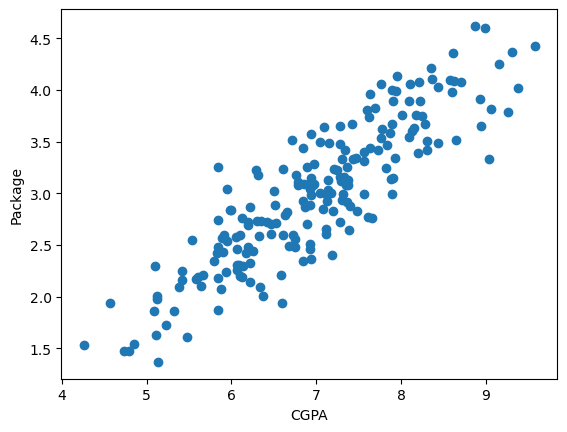

In [2]:
plt.scatter(df["cgpa"],df["package"])
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.show()

In [3]:
x = df[["cgpa"]] # This is a independent variable
y = df[["package"]] # This is a dependent variable

spliting the data in train and test where 80% of data will be for training and 20% for testing.

In [4]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=30)

In [5]:
x_train.shape,y_train.shape

((160, 1), (160, 1))

In [6]:
x_train

,cgpa
125,7.33
60,5.61
90,7.11
152,7.37
40,9.38
...,...
140,7.91
45,7.87
173,6.75
165,8.21


In [7]:
model = LinearRegression()


In [8]:
print(dir(model))

['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_decision_function', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_parameter_constraints', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_set_intercept', '_validate_data', '_validate_params', 'copy_X', 'fit', 'fit_intercept', 'get_metadata_routing', 'get_params', 'n_jobs', 'positive', 'predict

In [9]:
# Training the data
model.fit(x_train,y_train)

LinearRegression()

In [10]:
model.score(x_train,y_train) * 100

78.81146444150365

In [11]:
model.predict([[8.51]]),model.predict([[9.74]])

c:\Users\murtu\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\murtu\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


(array([[3.86641505]]), array([[4.5777021]]))

In [12]:
y_pred_test = model.predict(x_test)
y_pred_test

array([[1.74990235],
       [2.47275505],
       [3.75075862],
       [2.58841148],
       [2.44962376],
       [2.72141638],
       [2.36288144],
       [2.95272924],
       [3.16091082],
       [3.57727397],
       [3.44426907],
       [2.40336119],
       [2.90646667],
       [2.70985073],
       [2.49010351],
       [3.50209729],
       [2.07952318],
       [4.24229845],
       [2.87176974],
       [3.15512799],
       [3.34596111],
       [2.38601272],
       [2.44384094],
       [4.48517696],
       [2.76767895],
       [2.54214891],
       [3.63510219],
       [2.82550716],
       [3.54257704],
       [3.0221231 ],
       [3.1030826 ],
       [2.76189613],
       [2.40914401],
       [2.32240169],
       [2.91224949],
       [3.15512799],
       [1.90603853],
       [3.73341015],
       [1.58798335],
       [2.70406791]])

In [13]:
y_test

,package
143,1.54
81,2.20
26,3.42
150,2.73
124,2.31
24,2.71
126,2.60
142,3.04
129,3.12
171,3.76


In [14]:
r2_score(y_test,y_pred_test)

0.7196907227282943

In [15]:
import joblib

joblib.dump(model,"regresion_model.joblib")

['regresion_model.joblib']

In [16]:
joblib_model = joblib.load("regresion_model.joblib")


In [17]:
joblib_model.predict([[7.65]])

c:\Users\murtu\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[3.36909239]])

In [18]:
c = model.intercept_
c

array([-1.05476612])

In [19]:
m = model.coef_
m

array([[0.57828216]])

In [20]:
y = m * 7.65 + c
y

array([[3.36909239]])

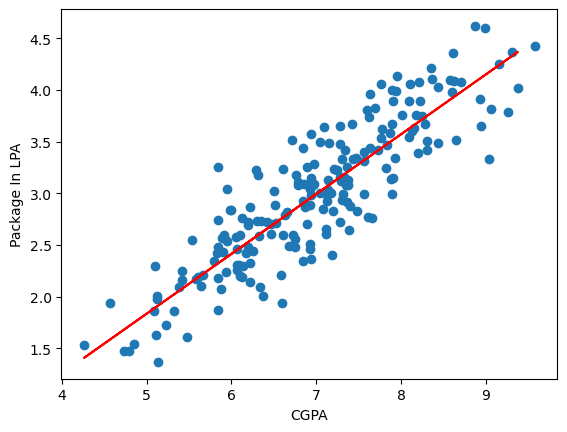

In [21]:
plt.scatter(df["cgpa"],df["package"])
plt.plot(x_train,model.predict(x_train),color = "red")
plt.xlabel("CGPA")
plt.ylabel("Package In LPA")
plt.show()